# Evaluación de modelos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

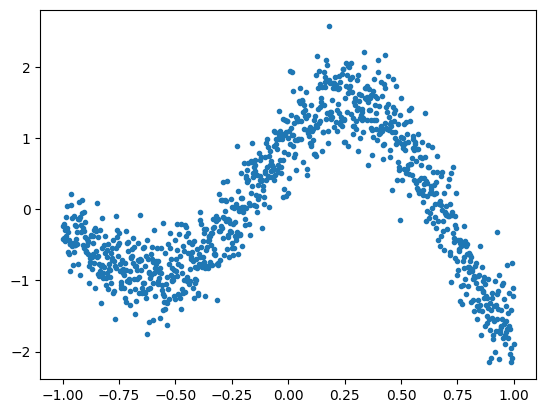

In [2]:
X = np.linspace(-1, 1, 1000)
ruido = np.random.normal(0, 0.333, 1000)
y = np.sin(4*X) + np.cos(3*X) + ruido
plt.plot(X,y, '.');

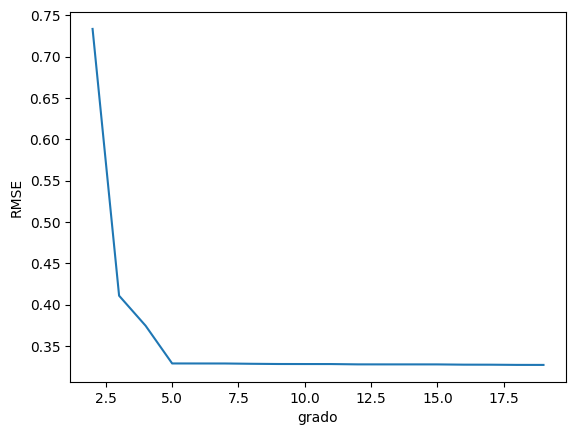

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

X = X.reshape(-1,1)

degrees = range(2,20)
scores_rmse = []
for degree in degrees:
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  X_p = poly.fit_transform(X)
  model = LinearRegression()
  model.fit(X_p, y)
  scores_rmse.append(root_mean_squared_error(y, model.predict(X_p)))

fig = plt.figure()
plt.plot(degrees, scores_rmse, '-')
plt.xlabel('grado')
plt.ylabel('RMSE');

# Errores de entrenamiento y prueba, sub-ajuste y sobre-ajuste

Parece que evidentemente el modelo mejora a medida que lo hacemos más complejo generando características de grados más elevados.

¿Dado lo anterior, podemos decir los modelos más complejos predicen mejor? Eso solo podemos saberlo con **datos diferentes** a los usados para entrenar el modelo.

En este caso vamos a generar un nuevo conjunto de datos con características estadísticas similares al del conjunto de datos que usamos para entrenar el modelo.

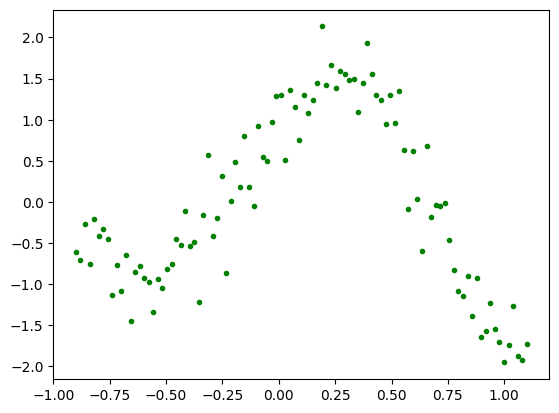

In [4]:
X_test = np.linspace(-0.9, 1.1, 100)
ruido = np.random.normal(0, 0.333, 100)
y_test = np.sin(4*X_test) + np.cos(3*X_test) + ruido
plt.plot(X_test, y_test, '.g');

Text(0, 0.5, 'RMSE')

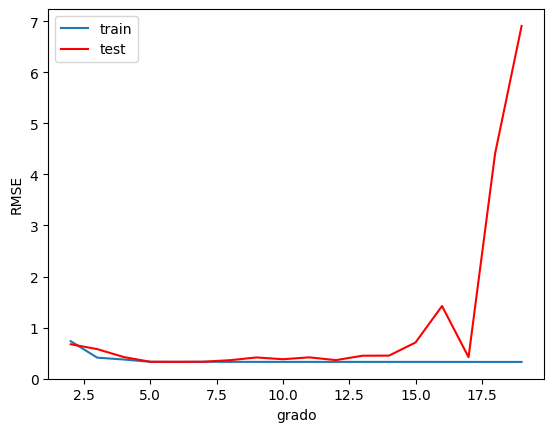

In [5]:
degrees = range(2,20)
scores_train = []
scores_test = []
for degree in degrees:
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  X_p = poly.fit_transform(X)
  X_test_p = poly.fit_transform(X_test.reshape(-1,1))
  model = LinearRegression()
  model.fit(X_p, y)
  scores_train.append(root_mean_squared_error(y, model.predict(X_p)))
  scores_test.append(root_mean_squared_error(y_test, model.predict(X_test_p)))
plt.plot(degrees, scores_train, '-', label='train')
plt.plot(degrees, scores_test, '-r', label='test')
plt.legend()
plt.xlabel('grado')
plt.ylabel('RMSE')

Se observa que a medida que aumenta la complejidad del modelo (en este caso a través del grado de la función polinómica cuyos coeficientes se quieren ajustar), el error del conjunto de datos de entrenamiento tiende a reducirse, pero en el caso del error con datos nuevos (que suelen llamarse conjunto de datos de **prueba**), el error se comporta distinto: disminuye hasta cierto grado de complejidad y después vuelve a aumentar.

Teniendo en cuenta lo anterior, se dice que sí aún no hemos llegado al **error de prueba** mìnimo que se puede obtener con ese modelo en particular, el modelo está **sub-ajustado**, y sí ya pasamos el mínimo y seguimos aumentando la complejidad del modelo lo estamos **sobre-ajustando**.

# Partición de los datos en conjuntos de entrenamiento y prueba

No siempre es posible tener un conjunto de datos nuevos, así que el conjunto de datos de prueba se suele extraer del conjunto de datos con que se cuenta. De esta manera, quedaremos con 2 conjuntos de datos, uno de entrenamiento y otro de prueba.

La partición de los datos debería hacerse de manera aleatoria, excepto con los datos de tiempo. El método train_test_split permite hacer esta partición fácilmente.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=15, train_size=0.8)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (800, 1)
Tamaño del conjunto de prueba es: (200, 1)


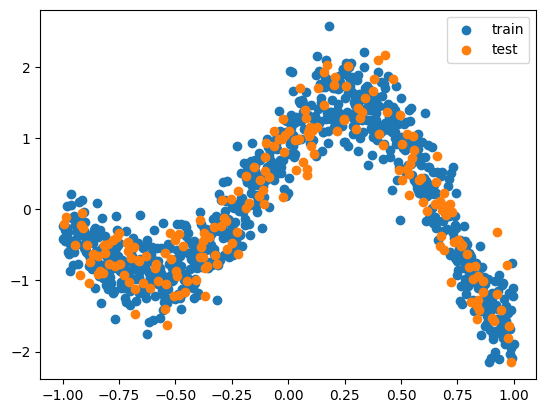

In [7]:
plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')
plt.legend()

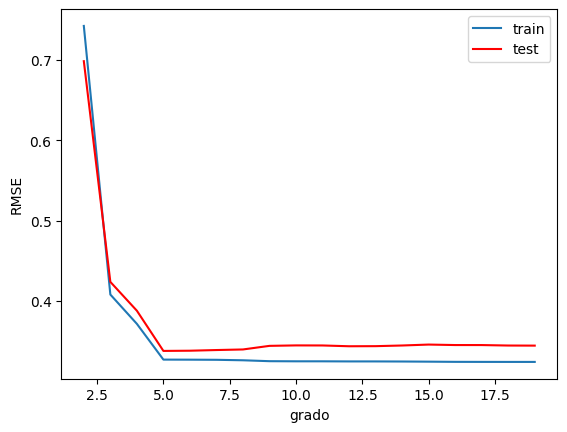

In [8]:
from sklearn.pipeline import Pipeline
degrees = range(2,20)
scores_train = []
scores_test = []
for degree in degrees:
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  X_train_p = poly.fit_transform(X_train)
  X_test_p = poly.fit_transform(X_test.reshape(-1,1))
  model = LinearRegression()
  model.fit(X_train_p, y_train)
  scores_train.append(root_mean_squared_error(y_train, model.predict(X_train_p)))
  scores_test.append(root_mean_squared_error(y_test, model.predict(X_test_p)))
plt.plot(degrees, scores_train, '-', label='train')
plt.plot(degrees, scores_test, '-r', label='test')
plt.legend()
plt.xlabel('grado')
plt.ylabel('RMSE');

¿Con esto quedamos tranquilos? En realidad no.

Para saber si nuestro modelo predice bien deberíamos **ajustarlo** con muchos conjuntos de entrenamiento y **evaluarlo** con muchos conjuntos de prueba. El promedio de los errores obtenidos en los conjuntos de prueba sería lo más cercano a un **error de generalización**.

Una forma de hacerlo es usando **validación cruzada**. En Scikit Learn el método cross_val_score me permite usar esta técnica de remuestreo.

In [9]:
from sklearn.model_selection import cross_val_score

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_p = poly.fit_transform(X_train)
scores = cross_val_score(estimator = model, X=X_train_p , y=y_train, cv=5, scoring='neg_root_mean_squared_error')
print(scores)
print('error promedio : ',-scores.mean())
print('desviación estándar del error: ', scores.std())
model.fit(X_train_p, y_train)
print('coeficientes del modelo: \n', model.coef_)

[-0.79967275 -0.70458612 -0.77915637 -0.72762656 -0.70837039]
error promedio :  0.7438824377310472
desviación estándar del error:  0.03853924979655084
coeficientes del modelo: 
 [ 0.35289636 -2.20795317]


In [10]:
poly = PolynomialFeatures(degree=5, include_bias=False)
X_train_p = poly.fit_transform(X_train)
scores = cross_val_score(estimator = model, X=X_train_p , y=y_train, cv=5, scoring='neg_root_mean_squared_error')
print(scores)
print('error promedio : ',-scores.mean())
print('desviación estándar del error: ', scores.std())
model.fit(X_train_p, y_train)
print('coeficientes del modelo: \n', model.coef_)

[-0.33998271 -0.3480569  -0.35572707 -0.29032995 -0.3154535 ]
error promedio :  0.3299100273758084
desviación estándar del error:  0.023970236435762002
coeficientes del modelo: 
 [ 3.87246454 -4.14718641 -9.09533128  2.24046098  4.55510087]


In [11]:
poly = PolynomialFeatures(degree=20, include_bias=False)
X_train_p = poly.fit_transform(X_train)
scores = cross_val_score(estimator = model, X=X_train_p , y=y_train, cv=5, scoring='neg_root_mean_squared_error')
print(scores)
print('error promedio : ',-scores.mean())
print('desviación estándar del error: ', scores.std())
model.fit(X_train_p, y_train)
print('coeficientes del modelo: \n', model.coef_)

[-0.34773904 -0.35410465 -0.3608177  -0.29399479 -0.33241903]
error promedio :  0.3378150412255148
desviación estándar del error:  0.02384236060262729
coeficientes del modelo: 
 [ 4.11705641e+00 -4.44760183e+00 -1.20327704e+01 -1.40442540e+01
 -2.40116612e+01  2.63797060e+02  4.94156578e+02 -1.85952523e+03
 -2.62771805e+03  7.37999703e+03  7.11695027e+03 -1.74223003e+04
 -1.08865504e+04  2.47025459e+04  9.45851424e+03 -2.05048249e+04
 -4.32858903e+03  9.12971731e+03  8.04592105e+02 -1.67277889e+03]


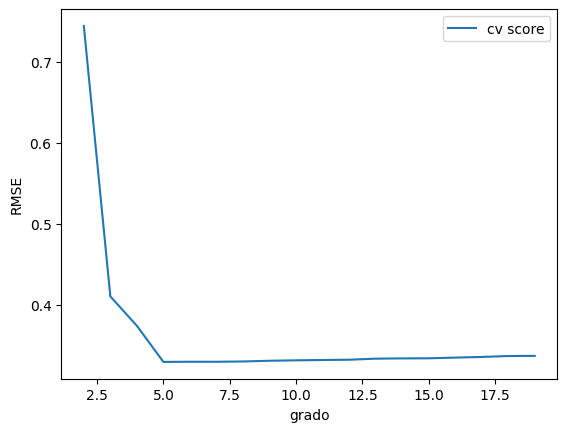

In [12]:
from sklearn.model_selection import cross_val_score

degrees = range(2,20)
mean_scores_cv = []
for degree in degrees:
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  X_train_p = poly.fit_transform(X_train)
  score = cross_val_score(estimator = model, X=X_train_p , y=y_train, cv=5, scoring='neg_root_mean_squared_error')
  mean_scores_cv.append(-score.mean())
plt.plot(degrees, mean_scores_cv, '-', label='cv score')
plt.legend()
plt.xlabel('grado')
plt.ylabel('RMSE');

Observamos que con grados grandes, mayores a 10, el RMSE del modelo se dispara. Vamos a hacer zoom en los modelos de grados más bajos.

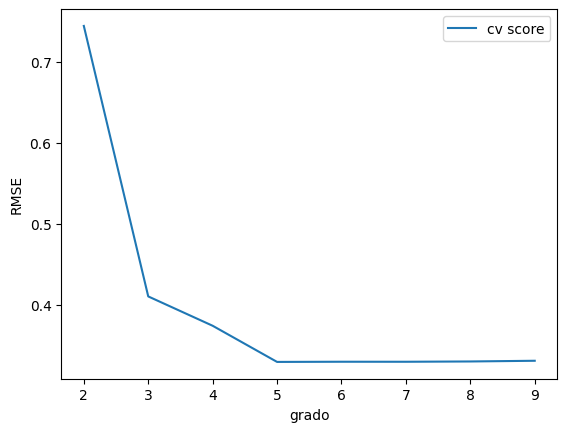

In [13]:
plt.plot(degrees[:8], mean_scores_cv[:8], '-', label='cv score')
plt.legend()
plt.xlabel('grado')
plt.ylabel('RMSE');

In [14]:
scores = pd.DataFrame(data = [degrees, mean_scores_cv], index=['grado', 'RMSE']).T
scores.set_index('grado', inplace=True)
scores

,RMSE
grado,
2.0,0.743882
3.0,0.410609
4.0,0.374455
5.0,0.329910
6.0,0.330137
7.0,0.330109
8.0,0.330471
9.0,0.331332
10.0,0.331882


El grado del polinomio que daría el menor error sería:

In [15]:
print(f'Best RMSE is {np.min(mean_scores_cv):.3f}, with degree {degrees[np.argmin(mean_scores_cv)]}.')

Best RMSE is 0.330, with degree 5.


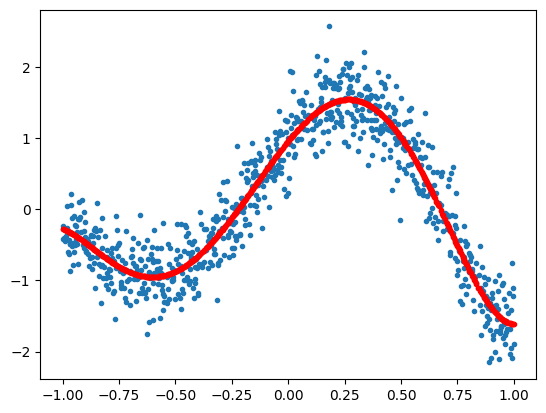

In [16]:
poly = PolynomialFeatures(degree=degrees[np.argmin(mean_scores_cv)], include_bias=False)
X_train_p = poly.fit_transform(X_train)

model.fit(X_train_p, y_train)
plt.plot(X_train, y_train, '.')
plt.plot(X_train, model.predict(X_train_p), 'r.');

También podría calcularse el error con el conjunto de prueba:

In [17]:
print(f'RMSE con conjunto de prueba: {root_mean_squared_error(y_test, model.predict(poly.fit_transform(X_test.reshape(-1,1)))):.3f}')

RMSE con conjunto de prueba: 0.338


Los coeficientes del modelo serían:

In [18]:
coeficientes = pd.DataFrame(model.coef_, index=poly.get_feature_names_out(), columns=['Coeficiente'])
coeficientes.loc['intercepto', 'Coeficiente'] = model.intercept_
coeficientes

,Coeficiente
x0,3.872465
x0^2,-4.147186
x0^3,-9.095331
x0^4,2.240461
x0^5,4.555101
intercepto,0.964990


# Ejercicio

Descargar el dataset 'auto-mpg.data-original', disponible en https://archive.ics.uci.edu/dataset/9/auto+mpg.

Prepare los datos.

Haga un modelo de regresión lineal polinómica que prediga la variable 'mpg' usando como variable predictora 'displacement'. Para esto haga una partición de los datos en subconjuntos de entrenamiento y prueba en una proporciòn 70/30, usando random_state=1.

Reporte el grado del polinomio óptimo, el RMSE de validación y el de prueba con el grado óptimo, el intercepto y las pendientes del modelo.